In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from numpy import exp as exp
import scipy.io as sio
import pandas as pd
from scipy.optimize import curve_fit

# Creation of folder for plots saving in png files

In [2]:
import os
folder_name = "figs_patches"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# vATPase function

In [3]:
# @jit
def J_v(pH_L, psi):
    
    psi_start, psi_end = -300, 300
    pH_start, pH_end = 0, 9
    
    if (pH_L < pH_start):
        pH_L = pH_start
    elif (pH_L > pH_end):
        pH_L = pH_end
    
    if (psi < psi_start):
        psi = psi_start
    elif (psi > psi_end):
        psi = psi_end
    
    p_a = 3.3654e-24*psi**10+-1.72718633e-21*psi**9+-1.88006118e-19*psi**8+1.84428806e-16*psi**7+1.14875767e-15*psi**6+-7.86180209e-12*psi**5+8.73621142e-11*psi**4+1.38612359e-07*psi**3+4.02706504e-06*psi**2+-0.000921991562*psi**1+0.892742811*psi**0
    p_b = -0.01183303*psi**1+-1.74410965*psi**0
    p_c = 1.97927106e-17*psi**8+-8.11163955e-15*psi**7+-1.41331765e-12*psi**6+7.37414295e-10*psi**5+2.69242151e-08*psi**4+-1.47727446e-05*psi**3+-0.0018809272*psi**2+0.0294192901*psi**1+122.27226*psi**0
    p_d = 3.32575786e-13*psi**6+-3.43339599e-11*psi**5+-5.76545216e-08*psi**4+7.89631331e-06*psi**3+0.00138326473*psi**2+0.11950506*psi**1+1.50734239*psi**0
    
    
    J = np.tanh(p_a*pH_L + p_b)*p_c-p_d
    return J*550/6


# Constants and initial values

In [4]:
# Physical constants
F = 96485      #[C] Na*e
NA = 6.02e+23   # Avogadro constant [Particles/mol]
RTF = 26.72        #RT/F [mV]} 

# Lysosome sizes
init_R = 0.34            #organelle radius [microns]
init_V = (4/3*3.1416*init_R**3*1e-12)/1000 #{surface area [cm**2]}
init_S = 4*3.1416*init_R**2*1e-8 #{lysosome volume  [liters]}

# cytosolic initial concentrations and pH
Ca_C = 1e-07      #[M]
Cl_C = 0.05      #[M]
Na_C = 0.015      #[M]
K_C = 0.145      #[M]
pH_C = 7.2     



# Selective ion transporters settings
# Stoichiometries of ion transporters
TMEM165_Ca = 1       # Calcium stoichiometry of TMEM165
TMEM165_H = 3        # Proton stoichiometry of TMEM165
CLC_Cl = 2       # Chloride stoichiometry of ClC-7
CLC_H = 1        # Proton stoichiometry of ClC-7

# Activities of ion transporters

N_CLC = 50      #Number of ClC-7 []
N_TPC = 38 #by patch 
N_TMEM = 1



init_Aeff = 0.3 #Initial effective activity of ClC-7
q = 2.2         # Coefficient for ClC-7
r = 0.1         #Deactivation to activation ratio for ClC-7
tau_act = 1     #Activation time for ClC-7 [s]
tau_deact = 0.25     #Activation time for ClC-7  for ClC-7 [s]
N_VATP = 6     #Number of vATPases []
N_NKA = 13000    #"Activity" of NKA []
p = 3.88e-12     #TRPML1 coefficient []

# Lysosome membrane permeabilities
P_Ca = 1.49e-7      #[ion*cm/s]
P_Cl = 1.2e-5       #[ion*cm/s]
P_H = 6e-05      #[ion*cm/s]
P_K = 7.1e-7 *1.6     #[ion*cm/s]
P_Na = 9.6e-7*686/1000      #[ion*cm/s]
Pw = 0.054e-2   #water permeability

# lysosome physical properties
beta_pH = 0.04      #[M/pH] Proton buffering capacity
cap = 1.45267584e-14      #[Farad] 
cap_0 = 1e-06      #[F/cm^2] membrane Bilayer capacitance 

# lysosome initial concentrations, potential and pH
init_Ca_F = 0.0005      #[M]
init_Ca_T = 0.005      #[M]
init_Cl = 0.1  #[M]
init_pH = 4.7
init_H = 0.05     #[M]
init_K = 0.07   #[M]
init_Na = 0.010   #[M]

psi_in = 0       #potential [mV]
psi_out = -50    #potential [mV]
# B is the concentration of Donnan particles, 
B = init_K+init_Na+init_H-init_Cl  + init_Ca_T*2 - cap/F/init_V*(psi_in - psi_out) 


      


# Osmolarities
Oc = 0.291
oh =  0.73
ok =  0.73
ona = 0.73
ocl = 0.73
Q = init_V*(Oc - (oh*10**(-init_pH) + ok*init_K + ona*init_Na + ocl*init_Cl))

# Derivatives

In [5]:
psi_t_lin = np.poly1d(np.polyfit([0, 6000], [-100, 100], 1))
I_coeff = np.ones(5)

In [6]:
def new_file(ion):
    file = f"{ion.lower()}_J_psi.txt"
    with open(file, 'w') as f:
        f.write("J psi\n") 

In [7]:
# @jit
# init_Na = 0.150
# Na_C = 0.150

def derivatives(X, t, ion = 'X', stress = 'No', CP = 0, LP = 0, coeff_list = [1, 1, 1]):
    '''
    compute derivatives of X wrt time
    '''
    Aeff, NH, pH, NK, NNa, NCl, NCa_T, NCa_F, R = X



    N_VATP = 7
    p = 3.88e-12

    P_Ca = 1.49e-7      #[ion*cm/s]
    P_Cl = 1.2e-5       #[ion*cm/s]
    P_H = 6.2e-05      #[ion*cm/s]
    P_K = 7.1e-7 *1.6     #[ion*cm/s]
    P_Na = 9.6e-7*686/1000      #[ion*cm/s]
    Pw = 0.054e-2   #water permeability

    pure_basefication = 0

    
     
    
    V = (4/3*3.1416*abs(R)**3*1e-12)/1000
    S = 4*3.1416*abs(R)**2*1e-8


    #Luminal Concentrations
    H = NH/V/NA
    K = NK/V/NA
    Na = NNa/V/NA
    Cl = NCl/V/NA
    Ca_F = NCa_F/V/NA
    Ca_T = NCa_T/V/NA
    r = Ca_F/Ca_T

    Ca_C = 1e-07      #[M]
    Cl_C = 0.05      #[M]
    Na_C = 0.015      #[M]
    K_C = 0.145      #[M]
    pH_C = 7.2     
    I_coeff = np.ones(5)
    if stress ==  'patch': 
        # print(ion)
        I_coeff = np.zeros(5)
        if ion == 'Na':
            Na_C = CP
            Na = LP
            # I_coeff[2] = 1
        if ion == 'K':
            K = LP
            K_C = CP
            # I_coeff[1] = 1
        if ion == 'Cl':
            Cl = LP
            Cl_C = CP
            # I_coeff[3] = 1
        if ion == 'H':
            pH = LP
            pH_C = CP
            # I_coeff[0] = 1
        # print(I_coeff)


    
    #membrane potential
    # psi = (F/cap)*init_V*(H + K + Na - Cl + 2*Ca_T - B)
    psi = (F/cap)*(V*(H + K + Na - Cl + 2*Ca_T) - B*init_V)
    
    if stress == 'patch':
        psi = psi_t_lin(t)


#      Modified Cytoplasmic Surface Concentrations
    pH_C0   = (pH_C+psi_out/(RTF*2.3))
    K_C0    = K_C*exp(-psi_out/RTF)
    Na_C0   = Na_C*exp(-psi_out/RTF) 
    Cl_C0   = Cl_C*exp(psi_out/RTF) 
    Ca_F_C0 = Ca_C*exp(-2*psi_out/RTF) 
    
#     Modified Luminal Surface Concentrations
    pH_L0   = (pH+psi_in/(RTF*2.3))
    K_L0    = K*exp(-psi_in/RTF)
    Na_L0   = Na*exp(-psi_in/RTF) 
    Cl_L0   = Cl*exp(psi_in/RTF) 
    Ca_F_L0 = Ca_F*exp(-2*psi_in/RTF) 

    if stress ==  'patch': 
    # print(ion)
        if ion == 'Na':
            Na_C0 = CP
            Na_L0 = LP
            # I_coeff[2] = 1
        if ion == 'K':
            K_L0 = LP
            K_C0 = CP


    delta_pH    = pH_C0-pH_L0;  

#     Treatment of singular terms for passive ion flux
    if (abs(psi) > 300):
        psi = np.sign(psi)*300
    if (abs(psi) > 0.01):
        gg      =  psi / (1 - exp (- psi / RTF)) / RTF
        gg_Ca   = 2*psi/(1-exp(-2*psi/RTF))/RTF

    else: 
        gg      =  1 / 1 - (psi / RTF)/2 + (psi / RTF)**2/6 - (psi / RTF)**3 / 24 + (psi / RTF) ** 4 / 120
        gg_Ca   = 1/(1 - (psi/RTF) + (2/3)*(psi/RTF)**2 - (1/3)*(psi/RTF)**3 +(2/15)*(psi/RTF)**4)


        

    # vAPTase
    J_VATPASE  = N_VATP * J_v(pH, psi)


        # ClC-7 Antiporter {H out, Cl in}
    CLC_mu      = (CLC_H + CLC_Cl)*psi + RTF*(CLC_H*2.3*delta_pH + CLC_Cl*np.log(Cl_C0/Cl_L0))
    
    #     Switching function   
    x = 0.5 + 0.5*np.tanh((CLC_mu + 250)/75); 
    # Activity
    A = 0.3*x + 1.5E-5*(1-x)*CLC_mu**2;
    
    if (A < Aeff):
        tau = tau_deact
    else:
        tau = tau_act
        
    J_CLC    = N_CLC*Aeff*CLC_mu 
    

    
    
    
    
#      Passive flux [ion/s]
    J_H = P_H*S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000
    J_K = P_K*S*(K_C0*exp(-psi/RTF)-K_L0)*gg*NA/1000 #this is TMEM
    J_Na = P_Na*S*(Na_C0*exp(-psi/RTF)-Na_L0)*gg*NA/1000
    J_Cl_unc = P_Cl*S*(Cl_C0-Cl_L0*exp(-psi/RTF))*gg*NA/1000
    J_Ca = P_Ca*S*(Ca_F_C0*exp(-2*psi/RTF)-Ca_F_L0)*gg_Ca*NA/1000
    


    
    #water flux
    J_w = Pw*S*(oh*10**(-pH) + ok*K + ona*Na + ocl*Cl + Q/V - Oc)
    
#     TRPML1 channel
    y = 0.5 - 0.5*np.tanh(psi + 40)
    P_trpml1 = p*(y*abs(psi) + (1-y)*(abs (psi + 40)**3)/(pH_L0**q))
    J_Ca_trpml1 = P_trpml1*S*(Ca_F_C0*exp(-2*psi/RTF)-Ca_F_L0)*gg_Ca*NA/1000



    #   TPC {Na out}
    
    xh = 6.7e3*exp(-0.9*pH) - 15
    k = 11.3*pH**2 - 116.5*pH + 325.3
    P_TPC = 1/(1+exp((xh-psi)/k))*1e-3
    J_TPC = N_TPC*P_TPC*S*(Na_C0*exp(-psi/RTF)-Na_L0)*gg*NA/1000
    J_Ca_TMEM165 = S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000-2*((TMEM165_H - 2*TMEM165_Ca)*psi + RTF*(TMEM165_Ca/2*np.log(Ca_F_L0/Ca_F_C0)))*1e6
    N_TMEM165 = 0.0000035*2

    file = 'na.txt'
    if t>0:
         with open(file, 'a') as f:
            
            J_NA_full = str(J_Na  + J_TPC)
            psi_str = str(psi)
            f.write(J_NA_full+ ' ' + psi_str+ '\n')
    if stress == 'Fast_vastpase_stress':
        if (t>500 and t<550):
            J_VATPASE = 0

    if stress == 'Fast_swelling':
        if (t>500 and t<550):
            J_w += 1e-13


    if NCa_T + (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1)<=0:
        J_Ca = 0
        J_Ca_trpml1 = 0
        J_Ca_TMEM165 = 0
        print('Ca concentration is too close to negative')

    # if (NCa_F + (J_Ca + (CAX_Ca*J_CAX) + J_Ca_trpml1)*r)<=0:
    #     J_Ca = 0
    #     J_CAX = 0
    #     J_Ca_trpml1 = 0
    #     print('!!')
    

    J_coef, TPC_coeff = coeff_list[0], coeff_list[1]
    J_coef = coeff_list[0]
    
    if stress == 'patch':
        file = ion+'_J_psi.txt'
        if ion == 'Na':
            J_full = J_Na*J_coef  + J_TPC*TPC_coeff
            # print(J_Na, N_NKA*J_vNa, J_TPC)
        if ion == 'K':
            J_full = (J_K*J_coef)*20
        if ion == 'Cl':
            J_full =J_Cl_unc
        if ion == 'H':
            file = ion+str(round(LP, 1))+'_J_psi.txt'
            # J_full = J_H + (J_VATPASE) - (CLC_H*J_CLC) - (CAX_H*J_CAX)
            J_full = J_H #TMEM
        if ion == 'Ca':
            J_full = J_Ca_trpml1

        with open(file, 'a') as f:
            J_str_full = str(J_full)
            psi_str = str(psi)
            f.write(J_str_full+ ' ' + psi_str+ '\n')
        
        
        




    dxdt = [(1/tau)*(A - Aeff),
        (J_H + (J_VATPASE) - (CLC_H*J_CLC) + (TMEM165_H*J_Ca_TMEM165*N_TMEM165) - pure_basefication)*I_coeff[0], 
           (-(J_H + (J_VATPASE) - (CLC_H*J_CLC) + (TMEM165_H*J_Ca_TMEM165*N_TMEM165) - pure_basefication)/V/NA)/beta_pH*I_coeff[0],
           (J_K)*I_coeff[1]*20,
           (J_Na*0.077  + J_TPC*0.686)*I_coeff[2],
           (J_Cl_unc + (CLC_Cl*J_CLC))*I_coeff[3],
           (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1)*I_coeff[4],
           ((J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1)*r)*I_coeff[4], 
           J_w/(1000*55)/(4*np.pi*(R/1e5)**2)*1e5*0]

    return dxdt

In [8]:
init_NH = init_H*init_V*NA;      #[ions]
init_NK = init_K*init_V*NA;       
init_NNa = init_Na*init_V*NA;    
init_NCl = init_Cl*init_V*NA;     
init_NCa_T = init_Ca_T*init_V*NA; 
init_NCa_F = init_Ca_F*init_V*NA; 

X0 = [init_Aeff, init_NH, init_pH, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R]

# Plots

In [9]:
def set_plot_font_params():
    """
    Set the font parameters for all plots in the Matplotlib instance.
    """
    # Set the font family and style
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Times new roman']
    plt.rcParams['font.style'] = 'normal'

    # Set the font sizes
    plt.rcParams['axes.labelsize'] = 30
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    plt.rcParams['legend.fontsize'] = 20
set_plot_font_params()

In [10]:
def J_to_A(J):
    return J*1.6e-19

In [11]:
#make txt file clear
def clear_txt_file(filename):
    with open(filename, 'w') as file:
        file.write('J psi'+'\n')

clear_txt_file('na.txt')

In [12]:
tspan = np.arange(0, 6000, 1e-2)
solution = odeint(derivatives, X0, tspan)

# tspan_stat = np.arange(0, 40000, 1e-2)
# solution_stat = odeint(derivatives, X0, tspan_stat)

In [13]:
real_Na_data = pd.read_csv('Na_real.txt', sep = ' ')
real_Na_data['J'] = real_Na_data['J']*1e-12

In [14]:
real_Na_data = pd.read_csv('Na_real.txt', sep = ' ')
real_Na_data['psi'] = -real_Na_data['psi']
real_Na_data['J'] = real_Na_data['J']*1e-12
x_data = real_Na_data['psi'].values
y_data = real_Na_data['J'].values

In [15]:
for i in ['Na', 'K', 'Cl', 'H']:
    clear_txt_file(i+'_J_psi.txt')

def Na_chanell_coefs(psi, A, B, C):
    A = A/1e3
    B = B/1e3
    C = C/1e3
    clear_txt_file('Na'+'_J_psi.txt')
    sol_Na = odeint(derivatives, X0, tspan, args = ('Na', 'patch', 0.150, 0.150, [A, B, C]))
    data = pd.read_csv('Na'+'_J_psi.txt', sep = ' ')
    # clear_txt_file('Na'+'_J_psi.txt')
    return J_to_A(np.interp(psi, data['psi'], data['J']))


# popt, pcov = curve_fit(Na_chanell_coefs, x_data, y_data, p0=[1, 1, 1])

popt, pcov = curve_fit(Na_chanell_coefs, x_data, y_data, p0=[1, 1, 1], maxfev = 1000000)
# popt, pcov = curve_fit(Na_chanell_coefs, x_data[0:9], y_data[0:9], p0=[70, 600], bounds=((0, 0), (+np.inf, +np.inf)), maxfev = 1000000)

# Get optimal A, B, C parameters
A_opt, B_opt, C_opt = popt
# plt.figure(figsize=(10, 6), dpi=600)
# Plot fitted curve
psi_range = np.linspace(min(x_data), max(x_data), 1000)
# plt.plot(x_data, -y_data*1e12, 'b.', label='Real data')
# plt.plot(psi_range, -Na_chanell_coefs(psi_range, A_opt, B_opt, C_opt)*1e12, 'r-', label='Model curve')
# # plt.plot(psi_range, Na_chanell_coefs(psi_range, 21120.327981713057, 536.8995793322276), 'gray', label='by me')

from sklearn.metrics import r2_score

y_pred = Na_chanell_coefs(x_data, A_opt, B_opt, C_opt)
r2 = r2_score(y_data, y_pred)
print(f"R-squared score: {r2}")

# plt.xlabel(r'$\psi$, mV')
# plt.ylabel('I, pA')
# plt.legend()
# plt.savefig('figs/Na_J_psi.png', dpi=600)
# plt.show()
# print(A_opt,B_opt,  C_opt)




C:\Users\yfal\anaconda3\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


R-squared score: 0.9903521886513018


R-squared score: 0.9903521886513018


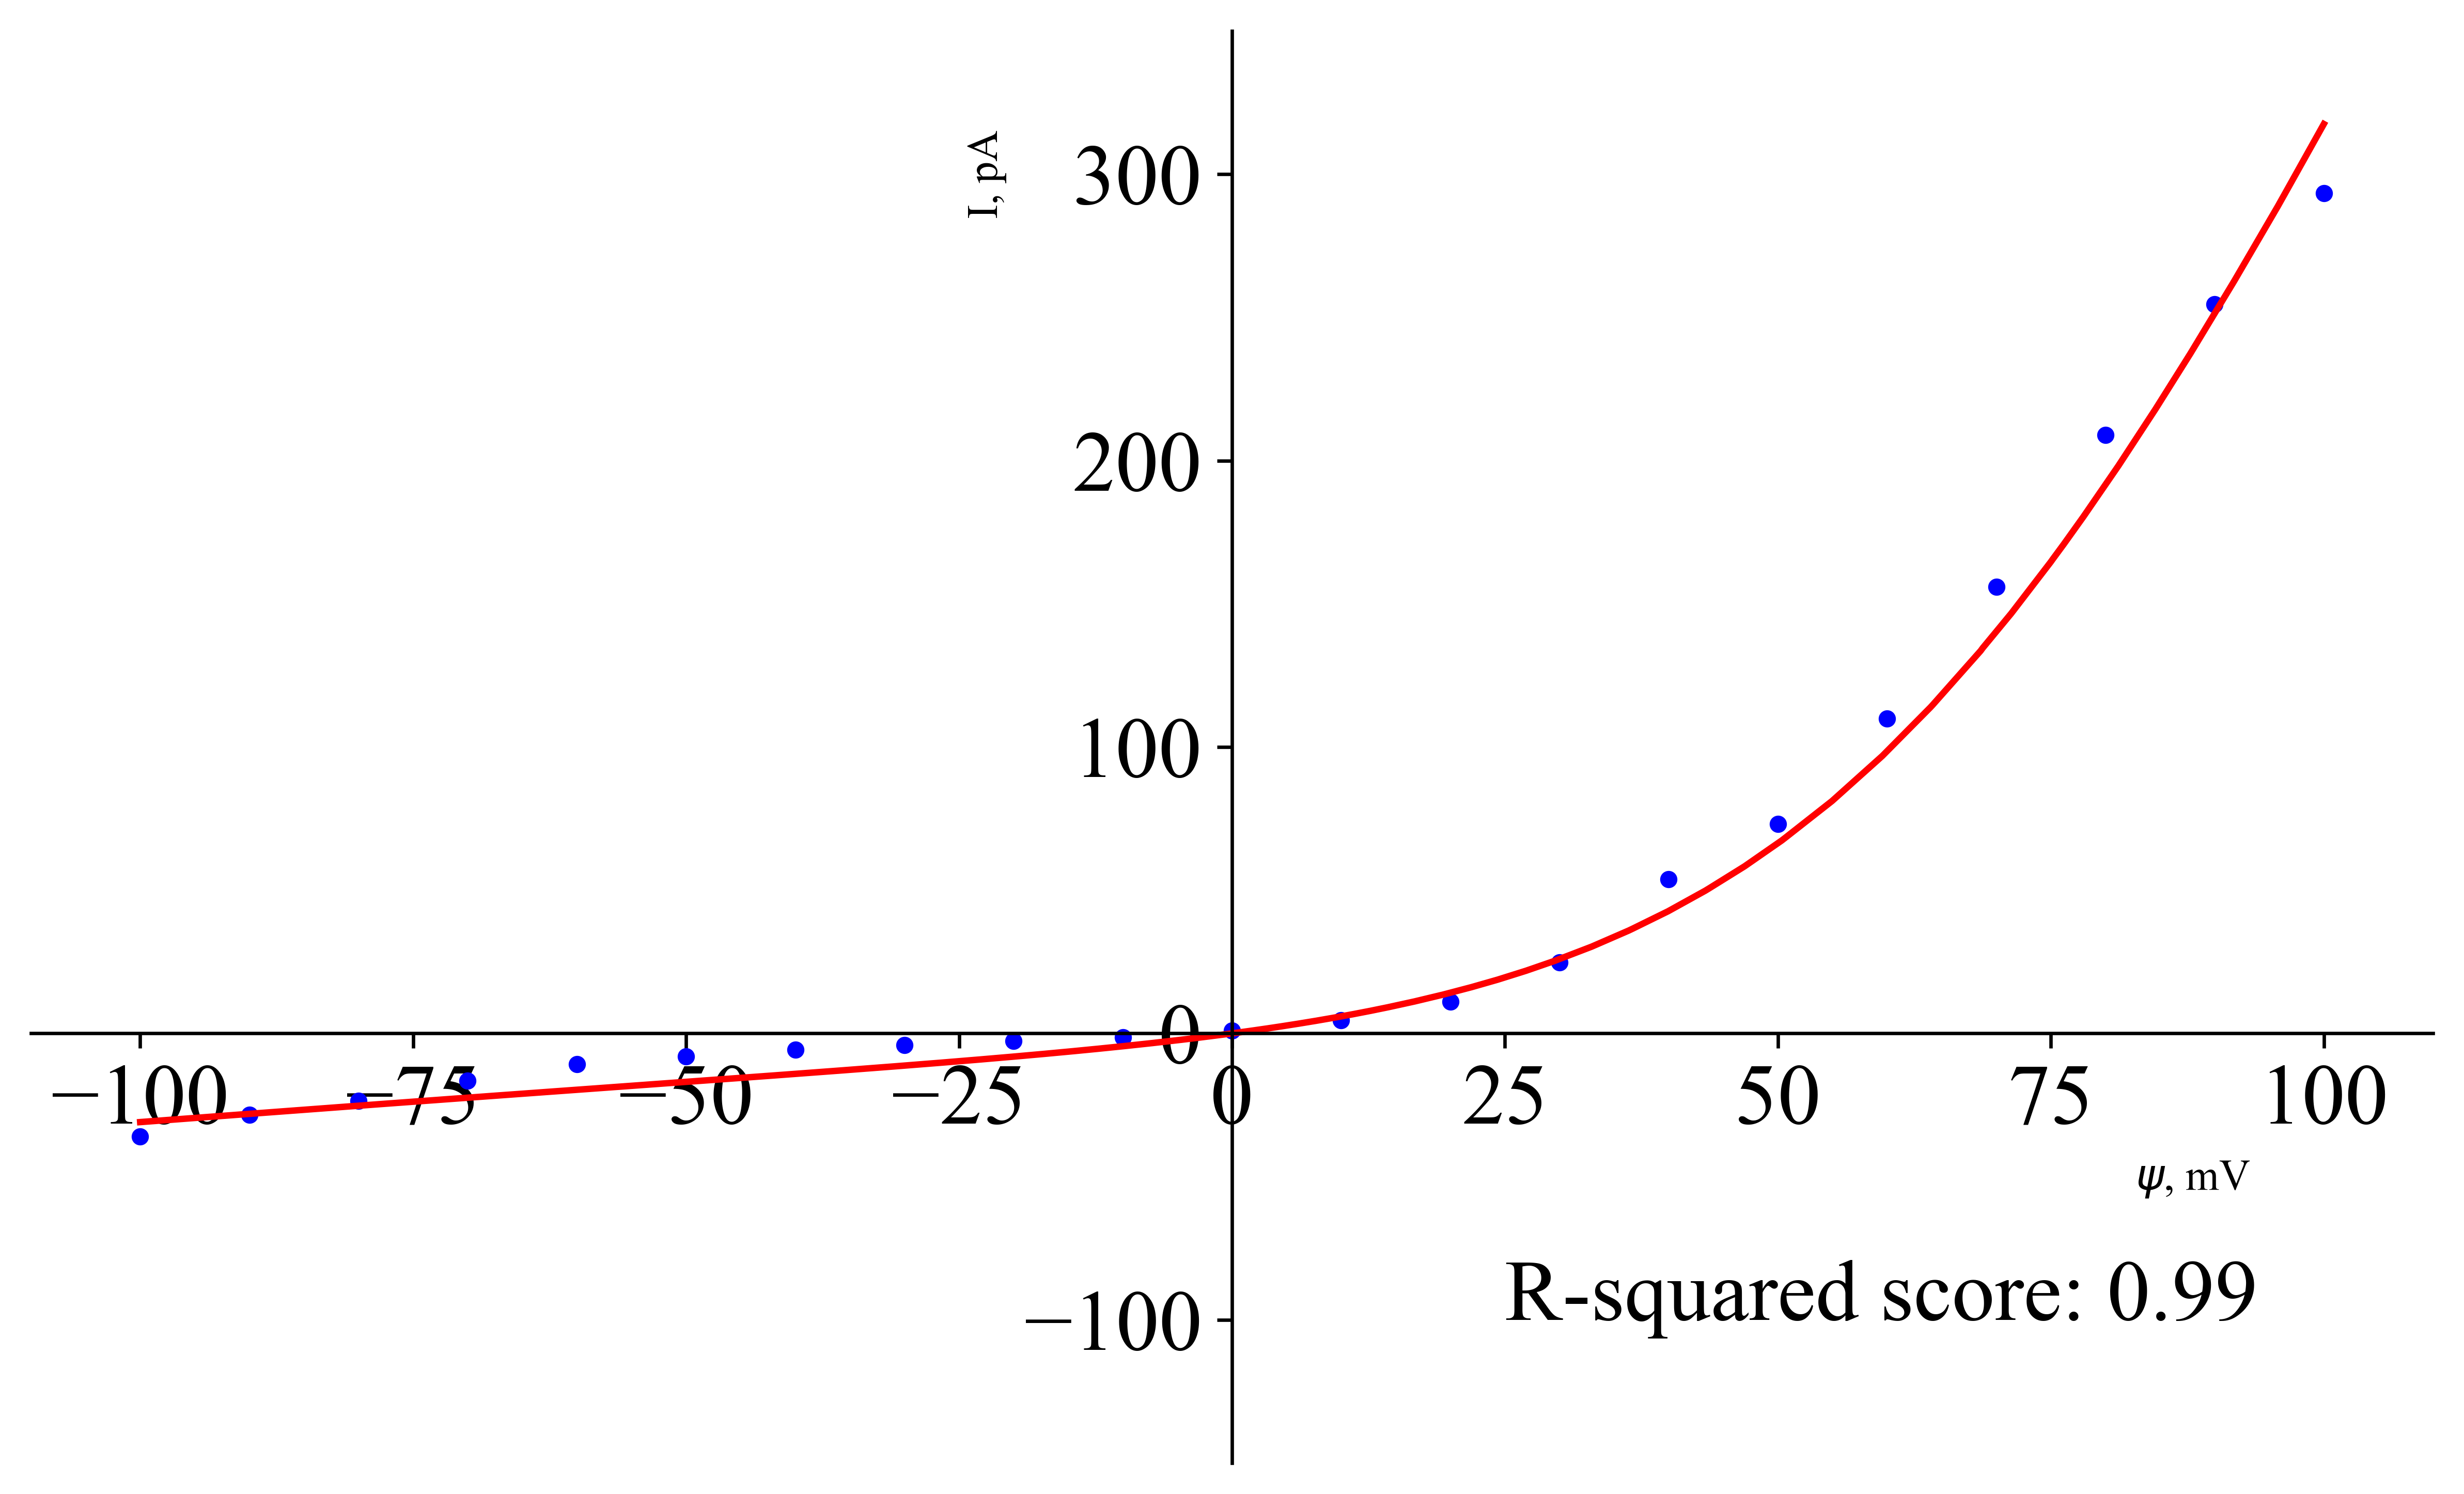

In [16]:
plt.figure(figsize=(10, 6), dpi=600)
psi_range = np.linspace(min(x_data), max(x_data), 1000)
plt.plot(x_data, -y_data*1e12, 'b.', label='Real data')
plt.plot(psi_range, -Na_chanell_coefs(psi_range, A_opt, B_opt, C_opt)*1e12, 'r-', label='Model curve')

plt.xlabel(r'$\psi$, mV', x=0.9)
# Position y-label on the top
plt.ylabel('I, pA', y=0.9)

ax = plt.gca()
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.ylim(-150, 350)
r2 = r2_score(y_data, y_pred)
print(f"R-squared score: {r2}")
plt.text(25, -100, f"R-squared score: {np.round(r2, 2)}", fontsize=20)


plt.savefig('figs_patches/Na_J_psi.png', dpi=600)
plt.show()

In [17]:
pKpatch = np.poly1d(np.polyfit([0, 1000], [-100, 100], 1))
real_K_data = pd.read_csv('K_real.txt', sep = ' ')
real_K_data['J'] = real_K_data['J']*1e-12
real_K_data['psi'] = -np.vectorize(pKpatch)(real_K_data['psi'])
real_K_data
x_data = real_K_data['psi'].values
y_data = real_K_data['J'].values

In [18]:
def K_chanell_coefs(psi, A, B, C):
    A = A/1e3
    B = 1
    C = C/1e3
    clear_txt_file('K'+'_J_psi.txt')
    sol_K = odeint(derivatives, X0, tspan, args = ('K', 'patch', 0.150, 0.150, [A, B, C]))
    data = pd.read_csv('K'+'_J_psi.txt', sep = ' ')
    # clear_txt_file('K'+'_J_psi.txt')
    return J_to_A(np.interp(psi, data['psi'], data['J']))


popt, pcov = curve_fit(K_chanell_coefs, x_data, y_data, p0=[1, 1, 1], maxfev = 1000000)
# popt, pcov = curve_fit(K_chanell_coefs, x_data[0:9], y_data[0:9], p0=[70, 600], bounds=((0, 0), (+np.inf, +np.inf)), maxfev = 1000000)

# Get optimal A, B, C parameters
A_opt, B_opt, C_opt = popt  
print('Optimal A, B, C parameters are: ', popt)
# Plot fitted curve
psi_range = np.linspace(min(x_data), max(x_data), 1000)


y_pred = K_chanell_coefs(x_data, A_opt, B_opt, C_opt)



C:\Users\yfal\anaconda3\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Optimal A, B, C parameters are:  [1.09802398e+03 1.00000000e+00 1.00000000e+00]


R-squared score: 0.9898142744723709


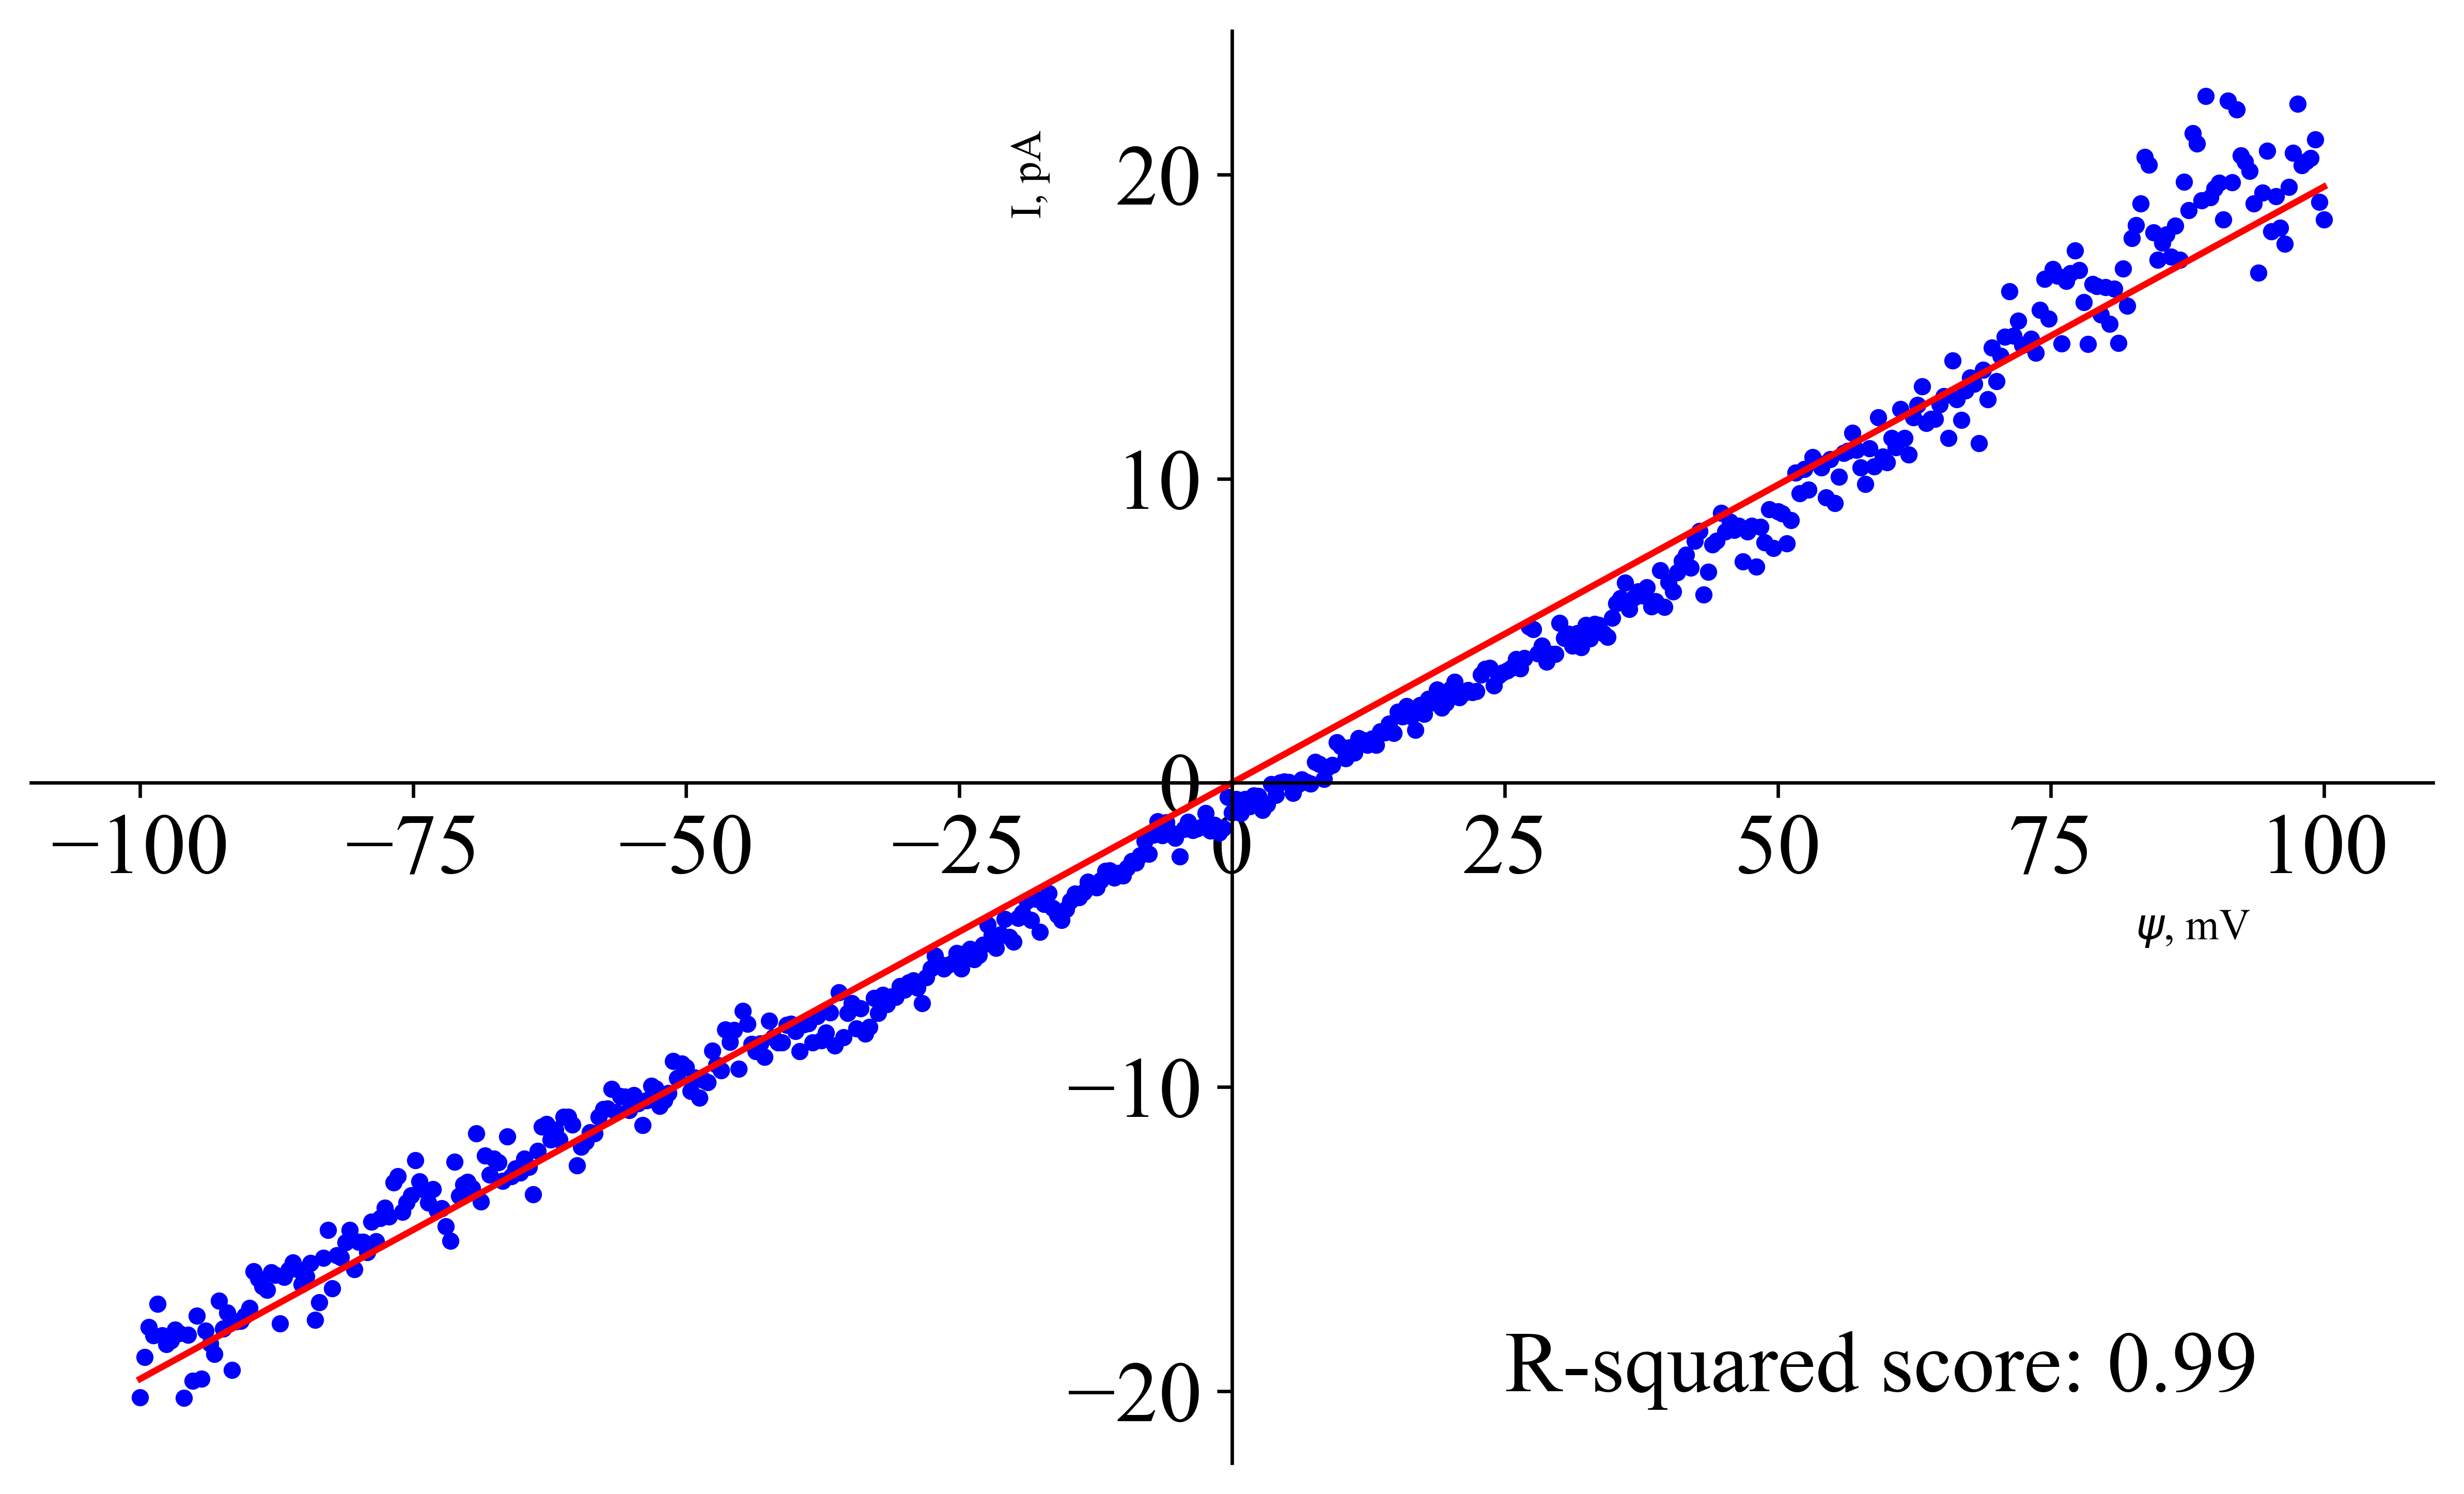

In [19]:
plt.figure(figsize=(10, 6), dpi=600)
psi_range = np.linspace(min(x_data), max(x_data), 1000)
plt.plot(x_data, -y_data*1e12, 'b.', label='Real data')
plt.plot(psi_range, -K_chanell_coefs(psi_range, A_opt, B_opt, C_opt)*1e12, 'r-', label='Model curve')

plt.xlabel(r'$\psi$, mV', x=0.9)
# Position y-label on the top
plt.ylabel('I, pA', y=0.9)

ax = plt.gca()
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
r2 = r2_score(y_data, y_pred)
print(f"R-squared score: {r2}")
plt.text(25, -20, f"R-squared score: {np.round(r2, 2)}", fontsize=20)

plt.savefig('figs_patches/K_J_psi.png', dpi=600)
plt.show()

In [20]:
pH_C_list = [3.5, 4.2, 4.6, 5.0, 7.2]
for i in pH_C_list:
    clear_txt_file('H'+str(round(i, 1))+'_J_psi.txt')

solutions = {
    '3.5': odeint(derivatives, X0, tspan,  args = ('H', 'patch', 7.2, 3.5)),
    '4.2': odeint(derivatives, X0, tspan,  args = ('H', 'patch', 7.2, 4.2)),
    '4.6': odeint(derivatives, X0, tspan, args = ('H', 'patch', 7.2, 4.6)),
    '5.0': odeint(derivatives, X0, tspan, args = ('H', 'patch', 7.2, 5.0)),
    '7.2': odeint(derivatives, X0, tspan, args = ('H', 'patch', 7.2, 7.2))
}



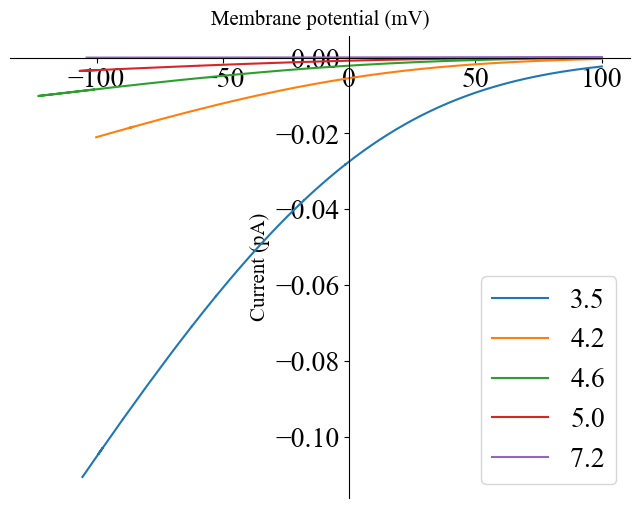

In [21]:
ion = 'H'
plt.figure(figsize=(8, 6))
for i, conc in enumerate(pH_C_list):          
    data = pd.read_csv(ion+str(round(conc, 1))+'_J_psi.txt', sep = ' ')
    plt.plot(-data['psi'], J_to_A(data['J']*1e12), label = str(round(conc, 1)))

    plt.legend()


# Move axes to cross at zero
ax = plt.gca()
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
plt.xlabel('Membrane potential (mV)', fontsize = 15)
plt.ylabel('Current (pA)', fontsize = 15)
plt.xlabel('Membrane potential (mV)', fontsize = 15, labelpad=-60)   
plt.savefig('figs_patches/H_J_psi.png', dpi=600)
